In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import skew, kurtosis

In [16]:
df = pd.read_csv("student_performance.csv")
df.head(20)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A
5,6,13.4,65.1,5.0,97.5,A
6,7,26.1,81.8,5.9,100.0,A
7,8,20.4,100.0,4.0,96.1,A
8,9,11.7,100.0,8.2,69.8,C
9,10,18.8,67.6,6.0,80.3,B


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [5]:
df.columns

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

In [6]:
duplicates = df[df.duplicated(keep=False)]

print(duplicates.sum())

student_id                   0
weekly_self_study_hours    0.0
attendance_percentage      0.0
class_participation        0.0
total_score                0.0
grade                        0
dtype: object


In [7]:
df.isna().sum(0)

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [8]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [9]:
print("Metode ini digunakan bukan untuk menarik kesimpulan dari data yang diperoleh,")
print("tetapi digunakan untuk memberitahu gambaran awal data sebelum proses lebih lanjut\n")

print("Statistik Deskriptif dari Total Score")
mean_score = df['total_score'].mean()
median_score = df['total_score'].median()
modus_score = df['total_score'].mode()[0]
mini_score = df['total_score'].min()
maxi_score = df['total_score'].max()

print(f"Mean\t: {mean_score:.2f}")
print(f"Median\t: {median_score}")
print(f"Modus\t: {modus_score}")
print(f"Minimum\t: {mini_score}")
print(f"Maximum\t: {maxi_score}\n")

jangkauan_score = df['total_score'].max() - df['total_score'].min()
simpangan_rata_rata_score = np.mean(np.abs(df['total_score'] - df['total_score'].mean()))
varian_score = df['total_score'].var()
std_deviasi_score = df['total_score'].std()

print(f"Jangkauan (Range)\t: {jangkauan_score}")
print(f"Simpangan Rata-Rata\t: {simpangan_rata_rata_score:.2f}")
print(f"Varians (Range)  \t: {varian_score:.2f}")
print(f"Standar Deviasi  \t: {std_deviasi_score:.2f}\n")

print("Statistik Deskriptif dari Weekly Self Study Hours")
mean_study = df['weekly_self_study_hours'].mean()
median_study = df['weekly_self_study_hours'].median()
modus_study = df['weekly_self_study_hours'].mode()[0]
mini_study = df['weekly_self_study_hours'].min()
maxi_study = df['weekly_self_study_hours'].max()

print(f"Mean\t: {mean_study:.2f}")
print(f"Median\t: {median_study}")
print(f"Modus\t: {modus_study}")
print(f"Minimum\t: {mini_study}")
print(f"Maximum\t: {maxi_study}\n")

jangkauan_study = df['weekly_self_study_hours'].max() - df['weekly_self_study_hours'].min()
simpangan_rata_rata_study = np.mean(np.abs(df['weekly_self_study_hours'] - df['weekly_self_study_hours'].mean()))
varian_study = df['weekly_self_study_hours'].var()
std_deviasi_study = df['weekly_self_study_hours'].std()

print(f"Jangkauan (Range)\t: {jangkauan_study}")
print(f"Simpangan Rata-Rata\t: {simpangan_rata_rata_study:.2f}")
print(f"Varians (Range)  \t: {varian_study:.2f}")
print(f"Standar Deviasi  \t: {std_deviasi_study:.2f}\n")

Metode ini digunakan bukan untuk menarik kesimpulan dari data yang diperoleh,
tetapi digunakan untuk memberitahu gambaran awal data sebelum proses lebih lanjut

Statistik Deskriptif dari Total Score
Mean	: 84.28
Median	: 87.5
Modus	: 100.0
Minimum	: 9.4
Maximum	: 100.0

Jangkauan (Range)	: 90.6
Simpangan Rata-Rata	: 12.91
Varians (Range)  	: 238.18
Standar Deviasi  	: 15.43

Statistik Deskriptif dari Weekly Self Study Hours
Mean	: 15.03
Median	: 15.0
Modus	: 0.0
Minimum	: 0.0
Maximum	: 40.0

Jangkauan (Range)	: 40.0
Simpangan Rata-Rata	: 5.55
Varians (Range)  	: 47.60
Standar Deviasi  	: 6.90



In [10]:
print("Metode ini digunakan untuk mengetahui keakuratan data diawal\n")

confidence = 0.95

print("Data Confidence weekly_self_study_hours")
n = len (df['weekly_self_study_hours'])
std_err = stats.sem(df['weekly_self_study_hours'])
ci_mean_study = stats.t.interval(confidence, df = n-1, loc = mean_study, scale = std_err)
ci_median_study = stats.t.interval(confidence, df = n-1, loc = median_study, scale = std_err)
ci_modus_study = stats.t.interval(confidence, df = n-1, loc = modus_study, scale = std_err)

print(f"Confidence Interval mean 95%\t: ({ci_mean_study[0]:.2f}, {ci_mean_study[1]:.2f})")
print(f"Confidence Interval median 95%\t: ({ci_median_study[0]:.2f}, {ci_median_study[1]:.2f})")
print(f"Confidence Interval modus 95%\t: ({ci_modus_study[0]:.2f}, {ci_modus_study[1]:.2f})\n")

print("Data Confidence total_score")
n = len (df['total_score'])
std_err = stats.sem(df['total_score'])
ci_mean_score = stats.t.interval(confidence, df = n-1, loc = mean_score, scale = std_err)
ci_median_score = stats.t.interval(confidence, df = n-1, loc = median_score, scale = std_err)
ci_modus_score = stats.t.interval(confidence, df = n-1, loc = modus_score, scale = std_err)
print(f"Confidence Interval mean 95%\t: ({ci_mean_score[0]:.2f}, {ci_mean_score[1]:.2f})")
print(f"Confidence Interval median 95%\t: ({ci_median_score[0]:.2f}, {ci_median_score[1]:.2f})")
print(f"Confidence Interval modus 95%\t: ({ci_modus_score[0]:.2f}, {ci_modus_score[1]:.2f})\n")

Metode ini digunakan untuk mengetahui keakuratan data diawal

Data Confidence weekly_self_study_hours
Confidence Interval mean 95%	: (15.02, 15.04)
Confidence Interval median 95%	: (14.99, 15.01)
Confidence Interval modus 95%	: (-0.01, 0.01)

Data Confidence total_score
Confidence Interval mean 95%	: (84.25, 84.31)
Confidence Interval median 95%	: (87.47, 87.53)
Confidence Interval modus 95%	: (99.97, 100.03)



In [11]:

print(f"Dengan tingkat kepercayaan 95%, nilai rata_rata data mean study_hours diperkirakan berada di antara {ci_mean_study[0]:.2f} hingga {ci_mean_study[1]:.2f},")
print(f"Dengan tingkat kepercayaan 95%, nilai rata-rata data median study_hours diperkirakan berada di antara {ci_median_study[0]:.2f} hingga {ci_median_study[1]:.2f},")
print(f"Dengan tingkat kepercayaan 95%, nilai rata-rata data modus study_hours diperkirakan berada di antara {ci_modus_study[0]:.2f} hingga {ci_modus_study[1]:.2f},")
print("sehingga nilai rata-rata sebenarnya kemungkinan besar berada dalam rentang tersebut.\n")


print(f"Dengan tingkat kepercayaan 95%, nilai rata-rata data mean total_score diperkirakan berada di antara {ci_mean_score[0]:.2f} hingga {ci_mean_score[1]:.2f},")
print(f"Dengan tingkat kepercayaan 95%, nilai rata-rata data median total_score diperkirakan berada di antara {ci_median_score[0]:.2f} hingga {ci_median_score[1]:.2f},")
print(f"Dengan tingkat kepercayaan 95%, nilai rata-rata data modus total_score diperkirakan berada di antara {ci_modus_score[0]:.2f} hingga {ci_modus_score[1]:.2f},")
print("sehingga nilai rata-rata sebenarnya kemungkinan besar berada dalam rentang tersebut.\n")

Dengan tingkat kepercayaan 95%, nilai rata_rata data mean study_hours diperkirakan berada di antara 15.02 hingga 15.04,
Dengan tingkat kepercayaan 95%, nilai rata-rata data median study_hours diperkirakan berada di antara 14.99 hingga 15.01,
Dengan tingkat kepercayaan 95%, nilai rata-rata data modus study_hours diperkirakan berada di antara -0.01 hingga 0.01,
sehingga nilai rata-rata sebenarnya kemungkinan besar berada dalam rentang tersebut.

Dengan tingkat kepercayaan 95%, nilai rata-rata data mean total_score diperkirakan berada di antara 84.25 hingga 84.31,
Dengan tingkat kepercayaan 95%, nilai rata-rata data median total_score diperkirakan berada di antara 87.47 hingga 87.53,
Dengan tingkat kepercayaan 95%, nilai rata-rata data modus total_score diperkirakan berada di antara 99.97 hingga 100.03,
sehingga nilai rata-rata sebenarnya kemungkinan besar berada dalam rentang tersebut.



In [12]:
print("Metode ini menunjukkan bahwa kedua data tersebut tidak memiliki outlier yang besar\n")
sk_score = df["total_score"].skew()
kurt_score = df["total_score"].kurtosis()

print("Skewness dan Kurtosis total score")
print(f"Skewness score : {sk_score:.2f}")
print(f"kurtosis score: {kurt_score:.2f}\n")

sk_study = df["weekly_self_study_hours"].skew()
kurt_study = df["weekly_self_study_hours"].kurtosis()

print("Skewness dan Kurtosis weekly self study hours")
print(f"Skewness study: {sk_study:.2f}")
print(f"kurtosis study: {kurt_study:.2f}")



Metode ini menunjukkan bahwa kedua data tersebut tidak memiliki outlier yang besar

Skewness dan Kurtosis total score
Skewness score : -0.82
kurtosis score: -0.12

Skewness dan Kurtosis weekly self study hours
Skewness study: 0.09
kurtosis study: -0.22


In [ ]:
# Boxplot sangat efektif untuk melihat median, kuartil, dan nilai ekstrem dalam dataset. 
# Grafik ini membantu dalam proses data cleaning dan memahami variasi data antar kelompok.

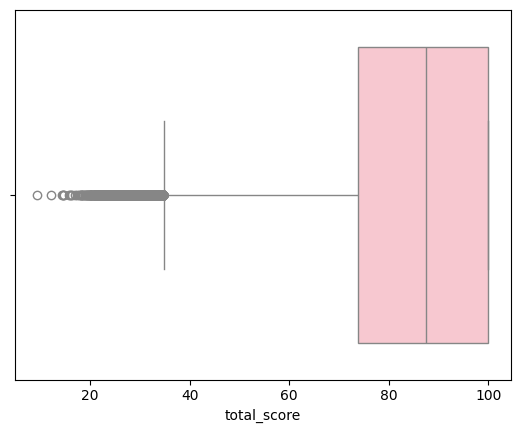

In [17]:
sns.boxplot(x=df["total_score"], color ='pink')

plt.show()

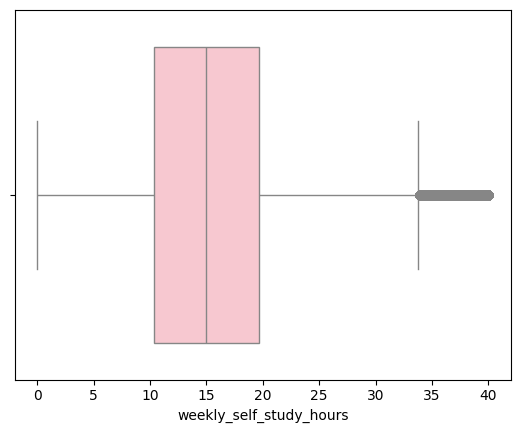

In [18]:
sns.boxplot(x=df["weekly_self_study_hours"] , color='pink')

plt.show()

In [19]:
Q1 = df["total_score"].quantile(0.25)
Q3 = df["total_score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["total_score"] < lower) |
    (df["total_score"] > upper)
]

print(len(outliers))
print("\n\n")
print(outliers)

2027



        student_id  weekly_self_study_hours  attendance_percentage  \
382            383                      0.1                  100.0   
668            669                      0.0                   86.4   
1539          1540                      0.0                   96.5   
2118          2119                      0.0                   79.8   
2344          2345                      0.0                   88.2   
...            ...                      ...                    ...   
999581      999582                      0.3                   87.8   
999733      999734                      0.1                   88.8   
999832      999833                      0.0                   90.9   
999887      999888                      3.5                   77.5   
999906      999907                      0.0                   82.3   

        class_participation  total_score grade  
382                     9.0         33.8     F  
668                     4.5         34.5     F  
1539

In [ ]:
# Histogram sangat tepat digunakan untuk melihat pola penyebaran data, seperti apakah nilai siswa cenderung tinggi, rendah, atau merata. 
# Grafik ini membantu mengidentifikasi distribusi data (normal, miring, atau tidak merata) serta mengetahui frekuensi kemunculan nilai dalam rentang tertentu.

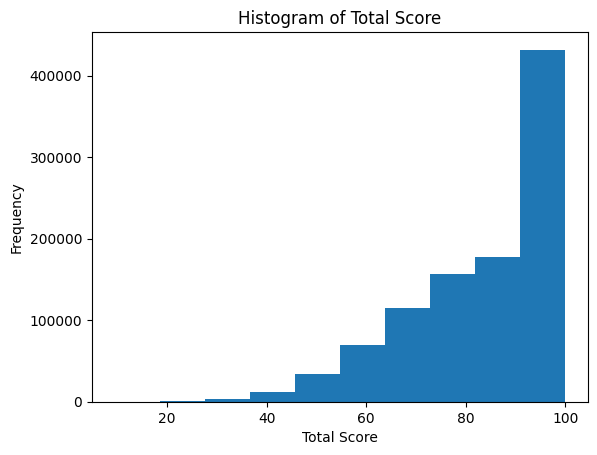

In [20]:
plt.figure()
plt.hist(df['total_score'])
plt.title('Histogram of Total Score')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.figure()
plt.hist(df['weekly_self_study_hours'])
plt.title('Histogram of Total Score')
plt.xlabel('Weekly Study Hours')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Scatterplot adalah grafik terbaik untuk menunjukkan korelasi atau hubungan antar variabel.
# Dalam dataset pendidikan, ini sangat penting untuk mengetahui apakah suatu faktor benar-benar mempengaruhi nilai.

In [ ]:
plt.figure()
plt.scatter(df['weekly_self_study_hours'], df['total_score'])
plt.title('Scatterplot of Study Hours vs Total Score')
plt.xlabel('Weekly Self Study Hours')
plt.ylabel('Total Score')
plt.show()